# SVM Individual Hyperparameter Trial - Gamma

Only `gamma` is varied; all feature data come from the one shared SVM cache.

This notebook **does not rescan audio or extract MFCCs**. It loads the shared SVM cache created by `00_SVM_Data_Preparation.ipynb`.


## 1. Environment Setup


In [1]:
import os
from pathlib import Path

# Purpose: Mounts Google Drive when this notebook is running in Google Colab.
# Why this exists: the shared SVM feature cache, manifests, configs, models,
# figures, and metric outputs may live under /content/drive/MyDrive in Colab.
# A /content/drive path is only reliable after Google Drive has actually been mounted.
# This cell is kept separate and early so the rest of the notebook can resolve paths safely.

COLAB_DRIVE_MOUNT_POINT = Path("/content/drive")
EXPECTED_COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")

try:
    from google.colab import drive

    drive.mount("/content/drive")
    os.environ.setdefault(
        "INTRO_AI_PROJECT_ROOT",
        str(EXPECTED_COLAB_PROJECT_ROOT),
    )
    print("Google Colab detected. Google Drive mounted.")
except Exception as exc:
    print("Google Colab Drive mount skipped. This is expected outside Colab.")
    print("Mount skip reason:", exc)

print("INTRO_AI_PROJECT_ROOT:", os.environ.get("INTRO_AI_PROJECT_ROOT", "not set"))


Mounted at /content/drive
Google Colab detected. Google Drive mounted.
INTRO_AI_PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Education/INM701


In [2]:
import importlib.util
import subprocess
import sys

required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("sklearn", "scikit-learn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("joblib", "joblib"),
]
missing = [pip_name for import_name, pip_name in required_packages if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Required packages are already installed.")


Required packages are already installed.


## 2. Load Shared SVM Cache


In [3]:
import json
import os
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.svm import SVC

try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42
SVM_MAX_TRAIN_SAMPLES = 20000
CLASS_NAMES = {0: "bona_fide", 1: "synthetic"}
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)


def resolve_project_root():
    explicit = os.environ.get("INTRO_AI_PROJECT_ROOT")
    if explicit:
        return Path(explicit).expanduser().resolve()
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "Data").exists() or (candidate / "Datasets").exists() or (candidate / "outputs").exists():
            return candidate
        if (candidate / "Model Variants").exists():
            return candidate
        if (candidate / "Training" / "Model Variants").exists():
            return candidate / "Training"
    return Path("/content/drive/MyDrive/Colab Notebooks/Education/INM701")


PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "svm"
CACHE_DIR = OUTPUT_DIR / "cache"
MANIFESTS_DIR = OUTPUT_DIR / "manifests"
CONFIGS_DIR = OUTPUT_DIR / "configs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
for directory in [OUTPUT_DIR, CACHE_DIR, MANIFESTS_DIR, CONFIGS_DIR, TABLE_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required shared-cache artifact not found: {path}. "
            "Run 00_SVM_Data_Preparation.ipynb first."
        )
    return path


def load_json(path):
    with open(require_file(path), "r", encoding="utf-8") as file:
        return json.load(file)


for required in [
    CACHE_DIR / "X_train.npy",
    CACHE_DIR / "y_train.npy",
    CACHE_DIR / "train_metadata.csv",
    CACHE_DIR / "X_validation.npy",
    CACHE_DIR / "y_validation.npy",
    CACHE_DIR / "validation_metadata.csv",
    CACHE_DIR / "feature_config.json",
    CACHE_DIR / "svm_standard_scaler.joblib",
]:
    require_file(required)

X_train_scaled = np.load(CACHE_DIR / "X_train.npy", mmap_mode="r")
y_train = np.load(CACHE_DIR / "y_train.npy")
train_metadata = pd.read_csv(CACHE_DIR / "train_metadata.csv")
X_validation_scaled = np.load(CACHE_DIR / "X_validation.npy", mmap_mode="r")
y_validation = np.load(CACHE_DIR / "y_validation.npy")
validation_metadata = pd.read_csv(CACHE_DIR / "validation_metadata.csv")
feature_config = load_json(CACHE_DIR / "feature_config.json")
scaler = joblib.load(CACHE_DIR / "svm_standard_scaler.joblib")

if len(X_train_scaled) != len(y_train) or len(X_train_scaled) != len(train_metadata):
    raise RuntimeError("Training cache arrays, labels and metadata are not row-aligned.")
if len(X_validation_scaled) != len(y_validation) or len(X_validation_scaled) != len(validation_metadata):
    raise RuntimeError("Validation cache arrays, labels and metadata are not row-aligned.")
if X_train_scaled.ndim != 2 or X_train_scaled.shape[1] != 80:
    raise RuntimeError(f"Expected 80-dimensional aggregated MFCC vectors, got {X_train_scaled.shape}")

LOAD_TEST_CACHE = False
if LOAD_TEST_CACHE:
    for required in [
        CACHE_DIR / "X_test.npy",
        CACHE_DIR / "y_test.npy",
        CACHE_DIR / "test_metadata.csv",
    ]:
        require_file(required)
    X_test_scaled = np.load(CACHE_DIR / "X_test.npy", mmap_mode="r")
    y_test = np.load(CACHE_DIR / "y_test.npy")
    test_metadata = pd.read_csv(CACHE_DIR / "test_metadata.csv")
    if len(X_test_scaled) != len(y_test) or len(X_test_scaled) != len(test_metadata):
        raise RuntimeError("Test cache arrays, labels and metadata are not row-aligned.")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Loaded shared SVM cache:", CACHE_DIR)
print("X_train shape:", X_train_scaled.shape)
print("X_validation shape:", X_validation_scaled.shape)
print("Test cache loaded:", LOAD_TEST_CACHE)


PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/Education/INM701
Loaded shared SVM cache: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/cache
X_train shape: (9060, 80)
X_validation shape: (1942, 80)
Test cache loaded: False


## 3. Reproducible SVM Training Subset


In [4]:
if len(y_train) > SVM_MAX_TRAIN_SAMPLES:
    selected = np.random.default_rng(RANDOM_STATE).choice(
        len(y_train), size=SVM_MAX_TRAIN_SAMPLES, replace=False
    )
    X_fit = X_train_scaled[selected]
    y_fit = y_train[selected]
    print(f"Training on the same reproducible {SVM_MAX_TRAIN_SAMPLES}-row subset.")
else:
    X_fit = X_train_scaled
    y_fit = y_train
    print(f"Training on all {len(y_fit)} training rows.")


Training on all 9060 training rows.


## 4. Evaluation Helper


In [5]:
def evaluate_classifier(model, X, y_true, variant, split_name):
    y_pred = model.predict(X)
    return {
        "variant": variant,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }, y_pred


## 5. Individual Hyperparameter Trial — gamma


In [6]:
# Only the target hyperparameter varies in this notebook.
svm_candidates = [
    {"variant": "gamma_0.0001", "kernel": "rbf", "C": 1.0, "gamma": 0.0001, "class_weight": "balanced"},
    {"variant": "gamma_0.001",  "kernel": "rbf", "C": 1.0, "gamma": 0.001,  "class_weight": "balanced"},
    {"variant": "gamma_0.01",   "kernel": "rbf", "C": 1.0, "gamma": 0.01,   "class_weight": "balanced"},
    {"variant": "gamma_0.1",    "kernel": "rbf", "C": 1.0, "gamma": 0.1,    "class_weight": "balanced"},
    {"variant": "gamma_1",      "kernel": "rbf", "C": 1.0, "gamma": 1.0,    "class_weight": "balanced"},
    {"variant": "gamma_scale",  "kernel": "rbf", "C": 1.0, "gamma": "scale", "class_weight": "balanced"},
    {"variant": "gamma_auto",   "kernel": "rbf", "C": 1.0, "gamma": "auto",  "class_weight": "balanced"},
]

validation_rows = []
trained_models = {}

for params in svm_candidates:
    model = SVC(
        kernel=params["kernel"],
        C=params["C"],
        gamma=params["gamma"],
        class_weight=params["class_weight"],
        random_state=RANDOM_STATE,
    )
    model.fit(X_fit, y_fit)

    metrics, _ = evaluate_classifier(
        model,
        X_validation_scaled,
        y_validation,
        params["variant"],
        "validation",
    )
    metrics.update({k: v for k, v in params.items() if k != "variant"})
    validation_rows.append(metrics)
    trained_models[params["variant"]] = model

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

validation_path = TABLE_DIR / "svm_gamma_trial.csv"
validation_results.to_csv(validation_path, index=False)
display(validation_results)

best_variant = validation_results.iloc[0]["variant"]
best_model = trained_models[best_variant]
best_value = validation_results.iloc[0]["gamma"]

print("Best gamma:", best_value)
print("Selected validation variant:", best_variant)
print("Best validation F1:", validation_results.iloc[0]["f1"])

# Save the best validation-stage model from this individual trial.
trial_model_path = MODEL_DIR / "svm_gamma_trial_best_validation_model.joblib"
joblib.dump(best_model, trial_model_path)
print("Saved trial results:", validation_path)
print("Saved best validation model:", trial_model_path)


,variant,split,accuracy,precision,recall,f1,kernel,C,gamma,class_weight
0,gamma_auto,validation,0.949537,0.994440,0.932241,0.962337,rbf,1.0,auto,balanced
1,gamma_scale,validation,0.949537,0.994440,0.932241,0.962337,rbf,1.0,scale,balanced
2,gamma_0.01,validation,0.946447,0.995204,0.927029,0.959907,rbf,1.0,0.01,balanced
3,gamma_0.1,validation,0.915036,0.908460,0.975428,0.940754,rbf,1.0,0.1,balanced
4,gamma_0.001,validation,0.886200,0.991243,0.842889,0.911066,rbf,1.0,0.001,balanced
5,gamma_0.0001,validation,0.826468,0.975425,0.768429,0.859642,rbf,1.0,0.0001,balanced
6,gamma_1,validation,0.691040,0.691396,0.999255,0.817296,rbf,1.0,1.0,balanced


Best gamma: auto
Selected validation variant: gamma_auto
Best validation F1: 0.962336664104535
Saved trial results: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/tables/svm_gamma_trial.csv
Saved best validation model: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/models/svm_gamma_trial_best_validation_model.joblib


## 6. Validation F1 Plot


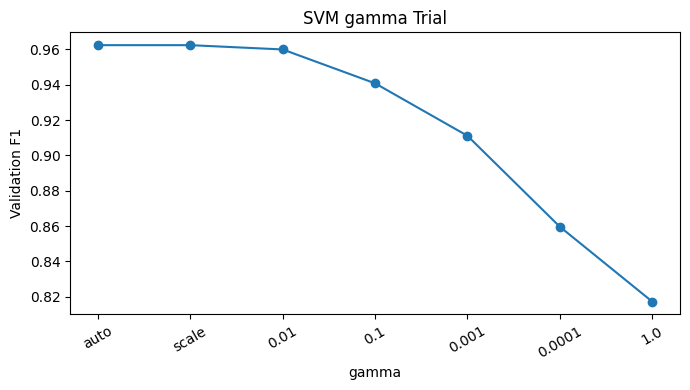

Saved plot: /content/drive/MyDrive/Colab Notebooks/Education/INM701/outputs/svm/figures/svm_gamma_trial.png


In [7]:
plot_results = validation_results.copy()
plot_results["plot_value"] = plot_results["gamma"].astype(str)

plt.figure(figsize=(7, 4))
plt.plot(plot_results["plot_value"], plot_results["f1"], marker="o")
plt.xlabel("gamma")
plt.ylabel("Validation F1")
plt.title("SVM gamma Trial")
plt.xticks(rotation=30)
plt.tight_layout()

plot_path = FIGURE_DIR / "svm_gamma_trial.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved plot:", plot_path)


## 7. Reproducibility Checks


In [8]:
print("Notebook: SVM Individual Hyperparameter Trial — Gamma")
print("Shared feature cache: Yes")
print("Audio rescanned here: No")
print("MFCCs recomputed here: No")
print("Scaler refitted here: No")
print("Random state:", RANDOM_STATE)
print("Feature representation:", feature_config["representation"])
print("Target hyperparameter varied: gamma")
print("Test split used in this notebook: No")


Notebook: SVM Individual Hyperparameter Trial — Gamma
Shared feature cache: Yes
Audio rescanned here: No
MFCCs recomputed here: No
Scaler refitted here: No
Random state: 42
Feature representation: aggregated MFCC mean+std (80 features), StandardScaler fitted on training only
Target hyperparameter varied: gamma
Test split used in this notebook: No
